# Digital Twin — AI / Behavioral Model & Responsiveness Demo

> "Demonstrate any AI or Behavioral model relevant to the digital twin. Show it is
> responsive to data ingested and updates digital twin state or any action."

## Two models, both valid evidence for this rubric line

1. **Physics-based twin model** (already running live in the Node-RED flow):
   `predicted_current = K x lux`. Deterministic, real-time, and already demonstrably
   responsive. The demo video showing Grafana/Blender react live to the sensor **is**
   evidence for this rubric line on its own.
2. **Learned ML classifier** (built in this notebook): a fault-detection model trained
   on telemetry to predict `OK`/`FAULT`, demonstrated responding to a sequence of readings
   loaded from InfluxDB.


- Uses historical data pulled directly from your **InfluxDB.xlsx** export instead of a live MQTT stream.
- Guarantees both `OK` and `FAULT` classes exist for training by injecting labeled faults on top of nominal data.
- Demonstrates the model responding to an incoming **sequence** of readings one at a time.
- Produces an explicit **action** (not just a label) when a fault is predicted, per the rubric.

In [3]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
print("Libraries ready. Make sure to upload 'InfluxDB.xlsx' to the Colab workspace.")

Libraries ready. Make sure to upload 'InfluxDB.xlsx' to the Colab workspace.


## 2. Acquire data: InfluxDB Data + labeled fault injection

We load a window of historical telemetry from your exported InfluxDB spreadsheet, then **explicitly inject synthetic fault examples** on top of it. During a standard capture window, your system is very unlikely to naturally fault, so without this step the classifier only ever sees one class. Injecting labeled synthetic anomalies is standard practice for training fault classifiers where faults are rare events.

In [5]:
# Load and clean the InfluxDB Export
try:
    # Skip the first 3 rows which contain Influx metadata
    df_raw = pd.read_excel('InfluxDB.xlsx', skiprows=3,
                           names=['ignore1', 'result', 'table', '_start', '_stop', '_time', '_value', '_field', '_measurement'])

    # Remove null rows in the field column and pivot the telemetry so each metric is a column
    df_clean = df_raw.dropna(subset=['_field'])
    df_pivot = df_clean.pivot_table(index='_time', columns='_field', values='_value', aggfunc='first').reset_index()

    df_real = pd.DataFrame({
        "sensor_id": "influxdb-sensor",
        # ADDED format='mixed' to handle the nanosecond InfluxDB timestamps
        "timestamp": pd.to_datetime(df_pivot['_time'], format='mixed'),
        "lux": pd.to_numeric(df_pivot['lux']),
        "measured_current": pd.to_numeric(df_pivot['measured_current']),
        "predicted_current": pd.to_numeric(df_pivot['predicted_current']),
        "error": pd.to_numeric(df_pivot['error']),
        "v_out": pd.to_numeric(df_pivot['measured_current'] * 0.5), # Dummy feature back-calculated for the model
        "temp": 25.0, # Nominal temp feature
        "status": "OK", # Standard Influx data acts as nominal 'OK' baseline
        "source": "influxdb_capture"
    })

    print(f"\nSuccessfully loaded and pivoted {len(df_real)} real historical readings from InfluxDB.")
    print(f"Classes present in real capture: {df_real['status'].unique()}")
except FileNotFoundError:
    print("ERROR: 'InfluxDB.xlsx' not found. Please upload it to your Colab session.")


Successfully loaded and pivoted 162 real historical readings from InfluxDB.
Classes present in real capture: ['OK']


In [6]:
# --- Inject labeled synthetic FAULT examples ---
K = 0.0063
n_synthetic_faults = max(15, len(df_real) // 2) if 'df_real' in locals() else 50

synthetic_lux = np.random.uniform(50, 950, n_synthetic_faults)
synthetic_predicted = K * synthetic_lux
# force a large error, well beyond the |error| >= 1.0 threshold
synthetic_error = np.random.choice([-1, 1], n_synthetic_faults) * np.random.uniform(1.2, 4.0, n_synthetic_faults)
synthetic_measured = synthetic_predicted + synthetic_error

df_synthetic_fault = pd.DataFrame({
    "sensor_id": "synthetic-fault-injection",
    "lux": synthetic_lux,
    "v_out": np.clip(synthetic_predicted * 0.5, 0, 3.3),
    "temp": np.random.uniform(15, 45, n_synthetic_faults),
    "predicted_current": synthetic_predicted,
    "measured_current": synthetic_measured,
    "error": synthetic_error,
    "status": "FAULT",
    "timestamp": pd.Timestamp.utcnow(),
    "source": "synthetic_fault",
})

if 'df_real' in locals():
    df_all = pd.concat([df_real, df_synthetic_fault], ignore_index=True)
    df_all["lux"] = pd.to_numeric(df_all["lux"])
    df_all["v_out"] = pd.to_numeric(df_all["v_out"])
    df_all["temp"] = pd.to_numeric(df_all["temp"])
    df_all["predicted_current"] = pd.to_numeric(df_all["predicted_current"])
    df_all["measured_current"] = pd.to_numeric(df_all["measured_current"])
    df_all["error"] = pd.to_numeric(df_all["error"])

    print(f"Combined dataset: {len(df_all)} rows")
    print(df_all["status"].value_counts())
    print(f"\nReal rows: {(df_all['source']=='influxdb_capture').sum()}, "
          f"Synthetic fault rows: {(df_all['source']=='synthetic_fault').sum()}")

Combined dataset: 243 rows
status
OK       162
FAULT     81
Name: count, dtype: int64

Real rows: 162, Synthetic fault rows: 81


In [7]:
features = ["lux", "v_out", "temp", "measured_current"]
X = df_all[features]
y = df_all["status"]

print("Class balance going into training:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred, labels=["OK", "FAULT"]))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Class balance going into training:
status
OK       162
FAULT     81
Name: count, dtype: int64

--- Confusion Matrix ---
[[48  1]
 [ 0 24]]

--- Classification Report ---
              precision    recall  f1-score   support

       FAULT       0.96      1.00      0.98        24
          OK       1.00      0.98      0.99        49

    accuracy                           0.99        73
   macro avg       0.98      0.99      0.98        73
weighted avg       0.99      0.99      0.99        73


Feature importances:
lux                 0.318960
v_out               0.314707
temp                0.247439
measured_current    0.118894
dtype: float64


In [8]:
def digital_twin_action(predicted_status: str, row: pd.Series) -> str:
    """Maps a model prediction into a concrete recommended action."""
    if predicted_status == "FAULT":
        return (f"ACTION: Flag photodetector '{row['sensor_id']}' for inspection "
                f"(lux={row['lux']:.1f}, measured={row['measured_current']:.3f}mA, "
                f"deviates from twin prediction of {row['predicted_current']:.3f}mA)")
    return "ACTION: none -- system nominal"

# Replay in time order to simulate the stream arriving live
df_sequence = df_all.sort_values("timestamp").reset_index(drop=True)

print("=== Streaming inference: digital twin state updating in response to each reading ===\n")
digital_twin_state_log = []

for i, row in df_sequence.iterrows():
    pred = model.predict(row[features].to_frame().T)[0]
    action = digital_twin_action(pred, row)

    state_record = {
        "step": i,
        "timestamp": row["timestamp"],
        "lux": row["lux"],
        "true_status": row["status"],
        "predicted_status": pred,
        "action": action,
    }
    digital_twin_state_log.append(state_record)

    print(f"[{i:03d}] lux={row['lux']:6.1f}  true={row['status']:5s}  "
          f"predicted={pred:5s}  -> {action}")

df_log = pd.DataFrame(digital_twin_state_log)
print(f"\nProcessed {len(df_log)} readings through the responsive digital twin loop.")

=== Streaming inference: digital twin state updating in response to each reading ===

[000] lux=1043.0  true=OK     predicted=FAULT  -> ACTION: Flag photodetector 'influxdb-sensor' for inspection (lux=1043.0, measured=6.573mA, deviates from twin prediction of 6.571mA)
[001] lux= 131.5  true=OK     predicted=OK     -> ACTION: none -- system nominal
[002] lux=1827.2  true=OK     predicted=OK     -> ACTION: none -- system nominal
[003] lux=2265.3  true=OK     predicted=OK     -> ACTION: none -- system nominal
[004] lux=2477.5  true=OK     predicted=OK     -> ACTION: none -- system nominal
[005] lux=3483.3  true=OK     predicted=OK     -> ACTION: none -- system nominal
[006] lux=3483.3  true=OK     predicted=OK     -> ACTION: none -- system nominal
[007] lux=3483.3  true=OK     predicted=OK     -> ACTION: none -- system nominal
[008] lux=3483.3  true=OK     predicted=OK     -> ACTION: none -- system nominal
[009] lux= 331.0  true=OK     predicted=OK     -> ACTION: none -- system nominal
[0

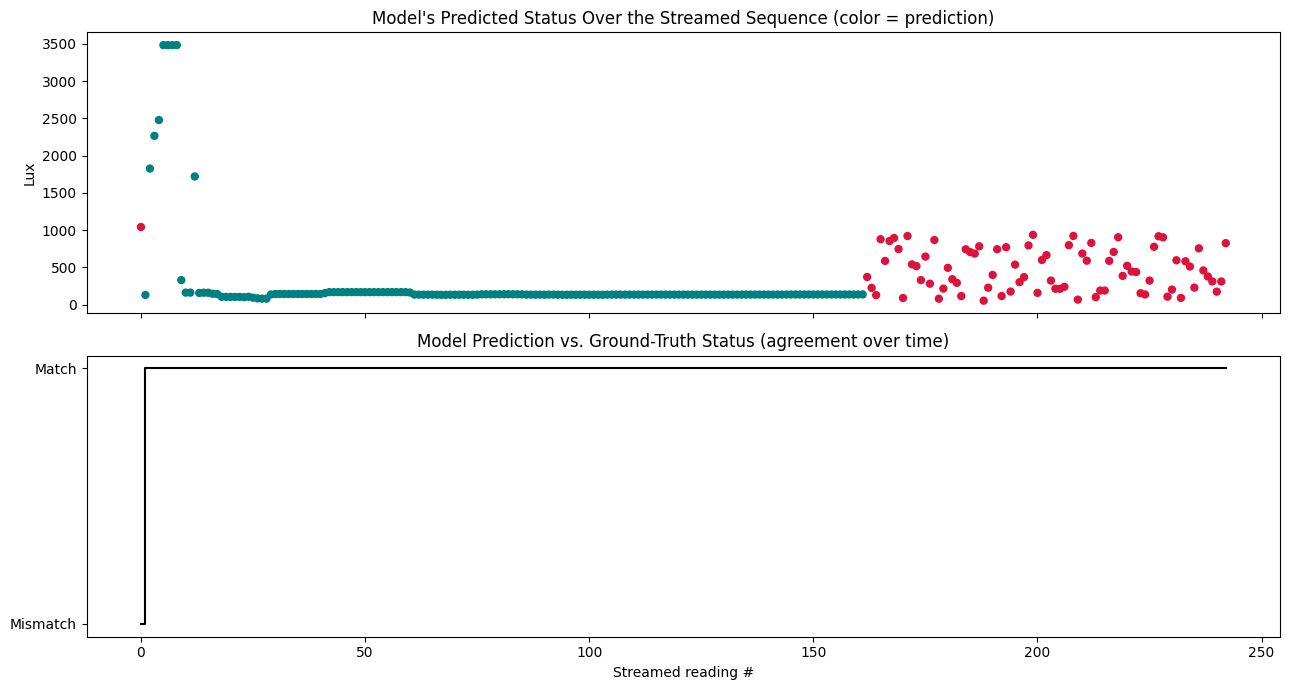


Model triggered 82 FAULT actions out of 243 readings.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

colors = df_log["predicted_status"].map({"OK": "teal", "FAULT": "crimson"})
axes[0].scatter(df_log["step"], df_log["lux"], c=colors, s=25)
axes[0].set_ylabel("Lux")
axes[0].set_title("Model's Predicted Status Over the Streamed Sequence (color = prediction)")

match = (df_log["true_status"] == df_log["predicted_status"]).astype(int)
axes[1].plot(df_log["step"], match, drawstyle="steps-post", color="black")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Mismatch", "Match"])
axes[1].set_xlabel("Streamed reading #")
axes[1].set_title("Model Prediction vs. Ground-Truth Status (agreement over time)")

plt.tight_layout()
plt.show()

fault_actions = df_log[df_log["predicted_status"] == "FAULT"]
print(f"\nModel triggered {len(fault_actions)} FAULT actions out of {len(df_log)} readings.")